# <center><span style="color:#336699">
SER347/CAP419 - Introdução a Programação com Dados Geoespaciais</span></center>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 200%;">
   PARTE 2 - Registro de imagens MUX L2 com base no Sentinel-2 <br/>
</div>


<br/>

<div style="text-align: center;font-size: 90%;">
    Carla Almeida e Tayná Florentino <sup><a href=""></i></a></sup>
    <br/><br/>
     Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Atualização: 23 de Maio de 2026
</div>

<br/>

<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;">
    <b>Resumo.</b> Essa segunda parte consiste em fazer o co-registro das imagens através de um  pacote do Python chamado AEROSICS. 
</div>

<br/>

### <span style="color:#336699">2.1. Criação do Ambiente Virtual e Dependências de Instalação </span>
<hr style="border:1px solid #0077b9;">

Para  evitar conflitos entre bibliotecas geoespaciais, a instalação do pacote **AROSICS** recomenda o uso do Anaconda ou Miniconda 

O pacote faz o gerenciamento  algoritmos complexos de processamento de imagens e depende de bibliotecas robustas de código aberto (como `GDAL`, `Shapely` e `pyproj`). O uso do gerenciador de pacotes padrão do Python (`pip`) **não é recomendado** pelos desenvolvedores, pois ele pode falhar ao compilar ou resolver as dependências dessas ferramentas geoespaciais.

> ⚠️ **Recomendação de Instalação:** O método preferido e estável é isolar o projeto em um ambiente virtual utilizando o **Anaconda** ou **Miniconda**, recorrendo ao canal comunitário `conda-forge`. O `conda` gerencia nativamente as dependências binárias complexas e garante a instalação da versão estável mais recente do AROSICS.

Abaixo estão descritos os comandos de terminal utilizados para a preparação do ambiente:

```bash
conda create -c conda-forge --name arosics python=3.11 -y
conda activate arosics
conda install -c conda-forge "arosics>=1.3.0" jupyter ipykernel -y

### <span style="color:#336699">2.2 Ativação do Pacote  AROSICS via Terminal </span>
<hr style="border:1px solid #0077b9;">

Rode os comandos abaixo no terminal para ativar o pacote: 

conda activate aerosics
jupyter notebook

<div align="center">
  <img src="conf/ativacao.png" width="600"/>
</div>

### <span style="color:#336699">2.3 Importação das bibliotecas</span>
<hr style="border:1px solid #0077b9;">

In [2]:
import os
import rasterio
from geoarray import GeoArray
from arosics import COREG_LOCAL

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### <span style="color:#336699">2.4 Leitura dos arquivos</span>
<hr style="border:1px solid #0077b9;">

Nessa parte  é realizado o carregamento das imagens em pares. 

In [4]:
# Definindo os pares de imagens (Referência -> Alvo)
pares_imagens = [
    {
        "ref": '/Users/carlaalmeida/Documents/python_qgis/Projeto/Copernicus/T24KVE_20260511T125321_B04.jp2',
        "alvo": '/Users/carlaalmeida/Documents/python_qgis/Projeto/CBERS4A/CBERS_4A_MUX_20260516_195_136_L2_BAND7.tiff',
        "sufixo": "B04_B7"
    },
    {
        "ref": '/Users/carlaalmeida/Documents/python_qgis/Projeto/Copernicus/T24KVE_20260511T125321_B08.jp2',
        "alvo": '/Users/carlaalmeida/Documents/python_qgis/Projeto/CBERS4A/CBERS_4A_MUX_20260516_195_136_L2_BAND8.tiff',
        "sufixo": "B08_B8"
    }
]

# Direcionando a pasta de saída
pasta_saida = '/Users/carlaalmeida/Documents/python_qgis/Projeto/novas_projecoes'
os.makedirs(pasta_saida, exist_ok=True)

print(f"Configuração concluída. Os arquivos corrigidos serão salvos em: {pasta_saida}")

Configuração concluída. Os arquivos corrigidos serão salvos em: /Users/carlaalmeida/Documents/python_qgis/Projeto/novas_projecoes


### <span style="color:#336699">2.5  Fazendo a configuração dos Parâmetros</span>
<hr style="border:1px solid #0077b9;">

- Nessa parte e realizado a leitura do conjunto de imagens de referência e a leitura da imagem alvo(no caso a que será aplicado o co-registro).
-  Uma imagem de satélite ela possui coordenadas geográficas. O GEORRAYS é uma classe da bibliteca  do AROSICS junta todas as informacoes em formato de objeto. 

- ref_ndarray / tgt_ndarray: Os dados puros da imagem. É uma matriz NumPy contendo os valores de brilho de cada pixel.
- ref_gt / tgt_gt: A escala e a origem. possuem coordenadas do canto da imagem, tamanho do pixel.
- ref_prj / tgt_prj: O sistema cartográfico. Modelo de  projeção cartográfica (o sistema de coordenadas, como UTM por exemplo).



########### INICIANDO PROCESSAMENTO: Par B04_B7 ############
-> Lendo Referência: T24KVE_20260511T125321_B04.jp2...
-> Lendo Alvo: CBERS_4A_MUX_20260516_195_136_L2_BAND7.tiff...
-> Transformando matrizes em GeoArray...
-> Instanciando COREG_LOCAL e calculando distorções...
Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(399960.0, 7890220.0, 509760.0, 8000020.0)
Automatically detected nodata value for GeoArray_CoReg 'IN_MEM': 0.0
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |============--------------------------------------| 25.0% Complete  => 0:00:00

Bounding box of calculated footprint for image to be shifted:
	(407120.0, 7918848.0, 522000.0, 8034192.0)
Matching window position (X,Y): 462804.0106095481/7963455.73741307
-> Aplicando correções geométricas e salvando arquivo final...
Initializing tie points grid...
Equalizing pixel grids and projections of reference and target image...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Calculating tie point grid (104 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:06
/Users/carlaalmeida/miniforge3/envs/arosics/lib/python3.11/site-packages/arosics/DeShifter.py:289: UserWarning: 
The coordinate grid of IN_MEM cannot be aligned to the desired grid because their pixel sizes are not exact multiples of each other (input [X/Y]: 16.0/16.0; desired [X/Y]: 10.0/10.0). Therefore the original grid is chosen for the resampled output image. If you don´t like that you can use the 'out_gsd' or 'match_gsd' parameters to set an appropriate output pixel size or to allow changing the pixel size.

  warnings.warn(f"\nThe coordinate grid of {self.im2shift.basename} cannot be aligned to the desired "
Translating progress |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |========------------------------------------------| 16.5% Complete  => 0:00:00

Found 21 matches.
Performing validity checks...
4 tie points flagged by level 1 filtering (reliability).
1 tie points flagged by level 2 filtering (SSIM).
17 valid tie points remain after filtering.
Automatically detected nodata value for GeoArray 'IN_MEM': 0.0
Correcting geometric shifts...


Warping progress     |===================================================| 101.9% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Writing GeoArray of size (7461, 7238) to /Users/carlaalmeida/Documents/python_qgis/Projeto/novas_projecoes/CBERS_corrigido_B04_B7.tif.
[SUCESSO] Imagem salva em: /Users/carlaalmeida/Documents/python_qgis/Projeto/novas_projecoes/CBERS_corrigido_B04_B7.tif
-> Plotando pontos de amarração para B04_B7...
Note: array has been downsampled to 1000 x 1000 for faster visualization.


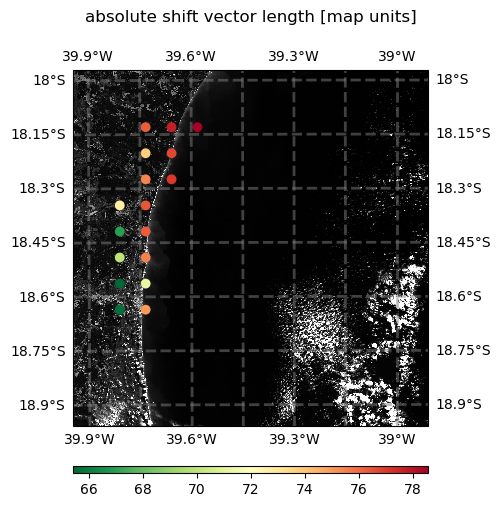


########### INICIANDO PROCESSAMENTO: Par B08_B8 ############
-> Lendo Referência: T24KVE_20260511T125321_B08.jp2...
-> Lendo Alvo: CBERS_4A_MUX_20260516_195_136_L2_BAND8.tiff...
-> Transformando matrizes em GeoArray...
-> Instanciando COREG_LOCAL e calculando distorções...
Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(399960.0, 7890220.0, 509760.0, 8000020.0)
Automatically detected nodata value for GeoArray_CoReg 'IN_MEM': 0.0
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |============--------------------------------------| 25.0% Complete  => 0:00:00

Bounding box of calculated footprint for image to be shifted:
	(407120.0, 7918848.0, 522000.0, 8034192.0)
Matching window position (X,Y): 462804.0106095481/7963455.73741307
-> Aplicando correções geométricas e salvando arquivo final...
Initializing tie points grid...
Equalizing pixel grids and projections of reference and target image...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Calculating tie point grid (104 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:04
/Users/carlaalmeida/miniforge3/envs/arosics/lib/python3.11/site-packages/arosics/Tie_Point_Grid.py:449: UserWarning: The following warnings were recorded during tie point computation:
- 1x (for ~1% of all tie point candidates): 	'UserWarning("\nAutomatic nodata value detection returned the value 1137.0 for GeoArray 'IN_MEM' but this seems to be unreliable (occurs in only 1 image corner). To avoid automatic detection, just pass the correct nodata value.")'
- 103x (for ~100% of all tie point candidates): 	'nan'
  warn("The following warnings were recorded during tie point computation:\n" +
/Users/carlaalmeida/miniforge3/envs/arosics/lib/python3.11/site-packages/arosics/DeShifter.py:289: UserWarning: 
The coordinate grid of IN_MEM cannot be aligned to the desired grid because their pixel sizes are not exact multiples of each other (input [X/Y]: 16.0/16.0; desired [X/Y]: 10.0/10.0). Therefore the or

Found 19 matches.
Performing validity checks...
1 tie points flagged by level 1 filtering (reliability).
0 tie points flagged by level 2 filtering (SSIM).
18 valid tie points remain after filtering.
Automatically detected nodata value for GeoArray 'IN_MEM': 0.0
Correcting geometric shifts...


Warping progress     |===================================================| 102.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Writing GeoArray of size (7461, 7238) to /Users/carlaalmeida/Documents/python_qgis/Projeto/novas_projecoes/CBERS_corrigido_B08_B8.tif.
[SUCESSO] Imagem salva em: /Users/carlaalmeida/Documents/python_qgis/Projeto/novas_projecoes/CBERS_corrigido_B08_B8.tif
-> Plotando pontos de amarração para B08_B8...
Note: array has been downsampled to 1000 x 1000 for faster visualization.


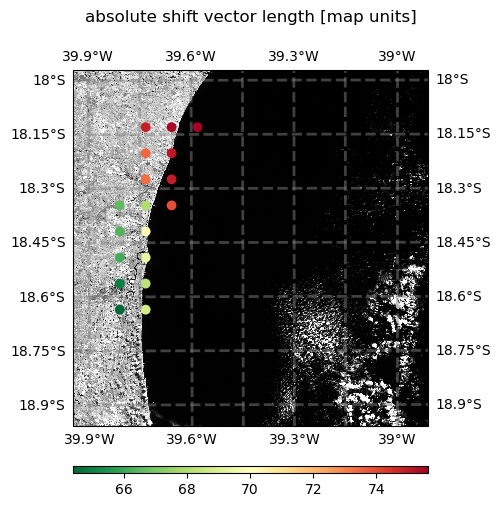


-- FIM DO PROCESSAMENTO: Todos os pares foram concluídos! --


In [5]:
for par in pares_imagens:
    print("\n" + "="*60)
    print(f" INICIANDO PROCESSAMENTO: Par {par['sufixo']} ".center(60, "#"))
    print("="*60)
    
    # --- 1. LEITURA DA IMAGEM DE REFERÊNCIA (Sentinel-2) ---
    nome_ref = os.path.basename(par['ref'])
    print(f"-> Lendo Referência: {nome_ref}...")
    with rasterio.open(par['ref']) as src_ref:
        ref_ndarray = src_ref.read(1)
        ref_gt = src_ref.transform.to_gdal()
        ref_prj = src_ref.crs.to_wkt()

    # --- 2. LEITURA DA IMAGEM ALVO (CBERS-4A) ---
    nome_alvo = os.path.basename(par['alvo'])
    print(f"-> Lendo Alvo: {nome_alvo}...")
    with rasterio.open(par['alvo']) as src_tgt:
        tgt_ndarray = src_tgt.read(1)
        tgt_gt = src_tgt.transform.to_gdal()
        tgt_prj = src_tgt.crs.to_wkt()

    # --- 3. CONFIGURAÇÃO DO NOME DE SAÍDA E PARÂMETROS ---
    caminho_saida_final = os.path.join(pasta_saida, f'CBERS_corrigido_{par["sufixo"]}.tif')

    kwargs = {
        'grid_res': 500,
        'window_size': (256, 256),
        'path_out': caminho_saida_final,
        'q': False,
        'tieP_filter_level': 2 
    }

    # --- 4. CRIAÇÃO DOS GEOARRAYS ---
    print("-> Transformando matrizes em GeoArray...")
    geo_ref = GeoArray(ref_ndarray, ref_gt, ref_prj)
    geo_tgt = GeoArray(tgt_ndarray, tgt_gt, tgt_prj)

    # --- 5. EXECUÇÃO DO CO-REGISTRO LOCAL E MAPA ---
    print("-> Instanciando COREG_LOCAL e calculando distorções...")
    CRL = COREG_LOCAL(geo_ref, geo_tgt, **kwargs)
    
    print("-> Aplicando correções geométricas e salvando arquivo final...")
    CRL.correct_shifts() 
    print(f"[SUCESSO] Imagem salva em: {caminho_saida_final}")
    
    # --- 6. EXIBIR O MAPA DE PONTOS NA TELA ---
    print(f"-> Plotando pontos de amarração para {par['sufixo']}...")
    CRL.view_CoRegPoints(figsize=(5,5), backgroundIm='ref')

print("\n" + "="*60)
print(" FIM DO PROCESSAMENTO: Todos os pares foram concluídos! ".center(60, "-"))
print("="*60)

### <span style="color:#336699">2.7  Imagem antes Co-Registro</span>
<hr style="border:1px solid #0077b9;">

## Primeiro Par de Imagens

- tie points(grade de pontos) - No primeiro par de imagem ele distribuiu 104 pela imagem com intuito de encontrar correspondência.
- 21 maches - Que parecem ser do mesmo local nas duas imagens
- Verificação se nao tinha falsos positivos (um ponto em uma plantação que mudou de cor por exemplo)
- 17 pontos válidos para ele conseguir esticar a imagem do CBERS sobre o Sentinel 2
-  
<hr style="border:1px solid #0077b9;">

## Segundo Par de Imagens

- tie points(grade de pontos) - No segundo par de imagem ele distribuiu 104 pela imagem com intuito de encontrar correspondência.
- 19 maches - Que parecem ser do mesmo local nas duas imagens
- Verificação se nao tinha falsos positivos (um ponto em uma plantação que mudou de cor por exemplo)
- 18 pontos válidos para ele conseguir esticar a imagem do CBERS sobre o Sentinel 2

<hr style="border:1px solid #0077b9;">

## O gradiente de cores mostra o tamanho do erro geométrico(o ponto exato de deslocamento antes da correção)

- Pontos Verdes: Significam que, naquela parte da imagem, o CBERS estava "quase" alinhado com o Sentinel. 
- Pontos Laranjas/Amarelos: Mostram um desalinhamento moderado.
- Pontos Vermelhos: Indicam as áreas onde o CBERS está mais desalinhado em relação ao Sentinel.
  
  
<div align="center">
  <img src="conf/antes_co_registro.png" width="800"/>
</div>

### <span style="color:#336699">2.6  Execução das Imagens após o  Co-Registro</span>
<hr style="border:1px solid #0077b9;">


############ VALIDAÇÃO PÓS-CORREÇÃO: Par B04_B7 ############
-> Cruzando Referência original: T24KVE_20260511T125321_B04.jp2
-> Com o Alvo já corrigido: CBERS_corrigido_B04_B7.tif...
-> Instanciando COREG_LOCAL para validação...
Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(399960.0, 7890220.0, 509760.0, 8000020.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for image to be shifted:
	(407088.0, 7918944.0, 521920.0, 8034256.0)
Matching window position (X,Y): 462765.5328960109/7963507.133953469
-> Gerando mapa de pontos pós-correção para B04_B7...


Warping progress     |===============================-------------------| 62.5% Complete  => 0:00:00

Note: array has been downsampled to 1000 x 1000 for faster visualization.
Initializing tie points grid...
Equalizing pixel grids and projections of reference and target image...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Calculating tie point grid (104 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:06


Found 22 matches.
Performing validity checks...
5 tie points flagged by level 1 filtering (reliability).
16 tie points flagged by level 2 filtering (SSIM).
3 valid tie points remain after filtering.


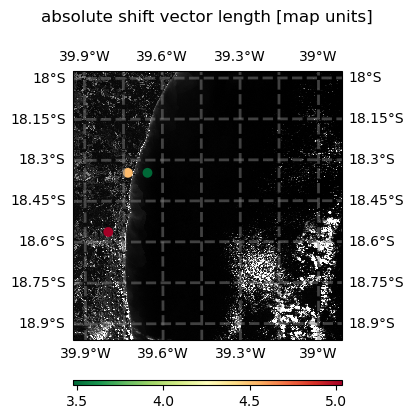


############ VALIDAÇÃO PÓS-CORREÇÃO: Par B08_B8 ############
-> Cruzando Referência original: T24KVE_20260511T125321_B08.jp2
-> Com o Alvo já corrigido: CBERS_corrigido_B08_B8.tif...
-> Instanciando COREG_LOCAL para validação...
Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(399960.0, 7890220.0, 509760.0, 8000020.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for image to be shifted:
	(407088.0, 7918912.0, 521936.0, 8034272.0)
Matching window position (X,Y): 462772.4673318849/7963494.913793048
-> Gerando mapa de pontos pós-correção para B08_B8...


Warping progress     |=====================================-------------| 75.0% Complete  => 0:00:00

Note: array has been downsampled to 1000 x 1000 for faster visualization.
Initializing tie points grid...
Equalizing pixel grids and projections of reference and target image...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Calculating tie point grid (104 points) using 8 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:04
/Users/carlaalmeida/miniforge3/envs/arosics/lib/python3.11/site-packages/arosics/Tie_Point_Grid.py:449: UserWarning: The following warnings were recorded during tie point computation:
- 1x (for ~1% of all tie point candidates): 	'UserWarning("\nAutomatic nodata value detection returned the value 1137.0 for GeoArray 'IN_MEM' but this seems to be unreliable (occurs in only 1 image corner). To avoid automatic detection, just pass the correct nodata value.")'
- 103x (for ~100% of all tie point candidates): 	'nan'
  warn("The following warnings were recorded during tie point computation:\n" +
/Users/carlaalmeida/miniforge3/envs/arosics/lib/python3.11/site-packages/arosics/CoReg_local.py:688: UserWarning: The map does not contain any tie points 
because all the found tie points were flagged as false-positives.
  warn(msg)


Found 20 matches.
Performing validity checks...
3 tie points flagged by level 1 filtering (reliability).
18 tie points flagged by level 2 filtering (SSIM).
0 valid tie points remain after filtering.


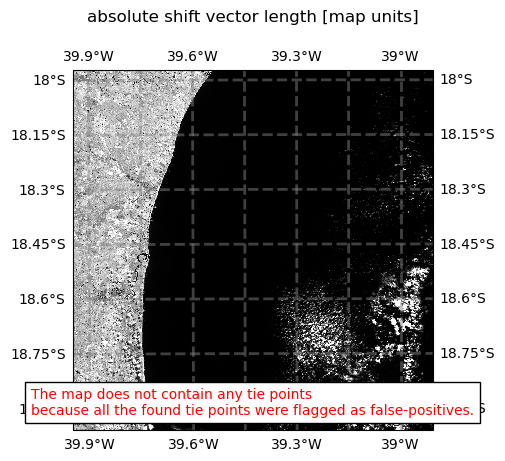


 FIM DA VALIDAÇÃO: Mapas pós-correção gerados com sucesso! -
Automatically detected nodata value for GeoArray 'IN_MEM': 1137.0


In [7]:
# Garantindo que o loop passe pelos dois pares configurados na sua lista
for par in pares_imagens:
    print("\n" + "="*60)
    print(f" VALIDAÇÃO PÓS-CORREÇÃO: Par {par['sufixo']} ".center(60, "#"))
    print("="*60)
    
    # 1. O caminho da referência muda dinamicamente (B04 na primeira rodada, B08 na segunda)
    im_reference = par['ref']
    nome_ref = os.path.basename(im_reference)
    
    # 2. Descobrimos o caminho do arquivo corrigido que salvamos no passo anterior
    caminho_corrigido = os.path.join(pasta_saida, f'CBERS_corrigido_{par["sufixo"]}.tif')
    nome_corrigido = os.path.basename(caminho_corrigido)
    
    print(f"-> Cruzando Referência original: {nome_ref}")
    print(f"-> Com o Alvo já corrigido: {nome_corrigido}...")

    # 3. Ajustamos os parâmetros (kwargs) para esta rodada de validação 
    kwargs_validacao = {
        'grid_res': 500,
        'window_size': (256, 256),
        'path_out': None,  # Não queremos salvar um novo tiff, apenas analisar na memória
        'q': False,
        'tieP_filter_level': 2 
    }

    # 4. Executa o co-registro posterior para visualização
    print("-> Instanciando COREG_LOCAL para validação...")
    CRL_after_corr = COREG_LOCAL(im_reference, caminho_corrigido, **kwargs_validacao)
    
    # 5. Plota o gráfico de pontos após a correção
    print(f"-> Gerando mapa de pontos pós-correção para {par['sufixo']}...")
    CRL_after_corr.view_CoRegPoints(figsize=(4,4), backgroundIm='ref')

print("\n" + "="*60)
print(" FIM DA VALIDAÇÃO: Mapas pós-correção gerados com sucesso! ".center(60, "-"))
print("="*60)

### <span style="color:#336699">2.7  Imagens pós Co-Registro</span>
<hr style="border:1px solid #0077b9;">

## Primeiro Par de Imagens

- tie points(grade de pontos) - No primeiro par de imagem ele distribuiu 104 pela imagem com intuito de encontrar correspondência.
- 22 maching - pontos de correspondência.
- 5 pontos ele descartou após a aplicacao do filtro de qualidade
- 16 pontos pelo filtro SSIM . Então ele compara a imagem do Sentinel com o CBERS para ver estruturas (brilho, contraste realmente combinam)
-  No caso somente esses 3 pontos passaram na verificação de qualidade. 

<hr style="border:1px solid #0077b9;">

## Segundo Par de Imagens

- tie points(grade de pontos) - No segundo par de imagem ele distribuiu 104 pela imagem com intuito de encontrar correspondência.
- 20 maching - pontos de correspondência 
- Como ele já tinha feito a correção e reamostragem o filtro de qualidade não detectou ditorções. Isso indica que como a imagem fui muito bem ajustada na primeira etapa, ele não encontrou nada. 

<hr style="border:1px solid #0077b9;">

## O gradiente de cores mostra o tamanho do erro geométrico(o ponto exato de deslocamento antes da correção)

- Pontos Verdes: Significam que, naquela parte da imagem, o CBERS estava "quase" alinhado com o Sentinel. 
- Pontos Laranjas/Amarelos: Mostram um desalinhamento moderado.
- Pontos Vermelhos: Indicam as áreas onde o CBERS está mais desalinhado em relação ao Sentinel.
  
  
<div align="center">
  <img src="conf/pos_co_registro.png" width="800"/>
</div>

### <span style="color:#336699">Referência Bibliográfica</span>
<hr style="border:1px solid #0077b9;">

AROSICS. Disponível em: https://danschef.git-pages.gfz-potsdam.de/arosics/doc/usage/local_coreg.html#visualize-tie-point-grid-with-initial-shifts-present-in-your-input-target-image. Acesso 27 Maio de 2026.